In [4]:
##Install the required libraries

!pip install pandas numpy matplotlib seaborn mlxtend openpyxl streamlit

In [5]:
## Import the lib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
## Load the dataset

df = pd.read_excel(r"C:\Users\Bhumika gs\ML Projects\Market Basket Analysis\data\Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
## check the dataset:

df.shape

(541909, 8)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [9]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [10]:
## Explore the dataset
# View first 10 rows

df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [11]:
# Check missing values

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [12]:
# Check duplicate records

df.duplicated().sum()

np.int64(5268)

In [13]:
# Check basic statistics

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [14]:
# Check unique values

print("Unique invoices:", df["InvoiceNo"].nunique())
print("Unique products:", df["StockCode"].nunique())
print("Unique customers:", df["CustomerID"].nunique())
print("Countries:", df["Country"].nunique())

Unique invoices: 25900
Unique products: 4070
Unique customers: 4372
Countries: 38


In [15]:
# Check cancelled transactions [In this dataset, invoices beginning with C represent cancellations.]

df["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
False    532621
True       9288
Name: count, dtype: int64

In [16]:
#Check negative quantities

(df["Quantity"] < 0).sum()

np.int64(10624)

In [17]:
# Check zero/negative prices

(df["UnitPrice"] <= 0).sum()

np.int64(2517)

In [18]:
## Data Cleaning
# Make a copy

df_clean = df.copy()

In [19]:
# Remove cancelled transactions

df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

In [20]:
# Check:

df_clean.shape

(532621, 8)

In [21]:
# Remove missing product descriptions [We need a product name to build our baskets.]

df_clean = df_clean.dropna(subset=["Description"])

In [22]:
# Check:

df_clean["Description"].isnull().sum()

np.int64(0)

In [23]:
# Keep only positive quantities

df_clean = df_clean[df_clean["Quantity"] > 0]

In [24]:
# Keep only positive prices
df_clean = df_clean[df_clean["UnitPrice"] > 0]

In [25]:
# Check the cleaned dataset

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 541909
Cleaned rows: 530104
Rows removed: 11805


In [26]:
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132220
Country             0
dtype: int64

In [27]:
# Check the cleaned data

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [28]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,530104.000000,530104,530104.000000,397884.000000
mean,10.542037,2011-07-04 20:16:05.225087,3.907625,15294.423453
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,1.000000,2011-03-28 12:22:00,1.250000,13969.000000
50%,3.000000,2011-07-20 12:58:00,2.080000,15159.000000
75%,10.000000,2011-10-19 12:39:00,4.130000,16795.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000
std,155.524124,NaN,35.915681,1713.141560


In [29]:
## Filter to the United Kingdom

df_uk = df_clean[df_clean["Country"] == "United Kingdom"].copy()

In [30]:
print("UK rows:", len(df_uk))
print("UK transactions:", df_uk["InvoiceNo"].nunique())

UK rows: 485123
UK transactions: 18019


In [31]:
#Create the basket matrix

basket = (
    df_uk
    .groupby(["InvoiceNo", "Description"])["Quantity"]
    .sum()
    .unstack()
    .fillna(0)
)

In [32]:
# Convert quantities into 0/1

#basket = (basket > 0).astype(int)

In [33]:
# Convert basket values to 0/1

basket = basket.fillna(0)
basket = (basket > 0).astype(bool)

In [34]:
# Check the result

basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TOADSTOOL BEDSIDE LIGHT,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536366,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536367,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536368,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536369,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [35]:
print(basket.dtypes.value_counts())

bool    4007
Name: count, dtype: int64


In [36]:
print(basket.iloc[:, :10].values.flatten()[:50])

[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False]


In [37]:
print("Minimum:", basket.astype(int).min().min())
print("Maximum:", basket.astype(int).max().max())

Minimum: 0
Maximum: 1


In [38]:
print(basket.shape)

(18019, 4007)


In [39]:
print("Number of transactions:", basket.shape[0])
print("Number of products:", basket.shape[1])

Number of transactions: 18019
Number of products: 4007


In [43]:
## Find Frequent Itemsets using Apriori [ start with minimum support of 1%.]
# Run Apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.014041,frozenset({ SET 2 TEA TOWELS I LOVE LONDON })
1,0.015151,frozenset({10 COLOUR SPACEBOY PEN})
2,0.013375,frozenset({12 MESSAGE CARDS WITH ENVELOPES})
3,0.018148,frozenset({12 PENCIL SMALL TUBE WOODLAND})
4,0.018813,frozenset({12 PENCILS SMALL TUBE RED RETROSPOT})


In [44]:
# Check how many itemsets we found

print("Number of frequent itemsets:", len(frequent_itemsets))


Number of frequent itemsets: 2156


In [45]:
# Sort by support

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
)

frequent_itemsets.head(20)

,support,itemsets
782,0.119984,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
357,0.107387,frozenset({JUMBO BAG RED RETROSPOT})
563,0.093512,frozenset({REGENCY CAKESTAND 3 TIER})
473,0.088407,frozenset({PARTY BUNTING})
397,0.077252,frozenset({LUNCH BAG RED RETROSPOT})
55,0.076086,frozenset({ASSORTED COLOUR BIRD ORNAMENT})
631,0.068872,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN })
426,0.067651,frozenset({NATURAL SLATE HEART CHALKBOARD })
389,0.067484,frozenset({LUNCH BAG BLACK SKULL.})
310,0.064598,frozenset({HEART OF WICKER SMALL})


In [46]:
frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

In [47]:
## Generate Association Rules
#Generate association rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3
)

In [48]:
print("Number of association rules:", len(rules))

Number of association rules: 184


In [49]:
# Look at the rules

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({60 TEATIME FAIRY CAKE CASES}),frozenset({PACK OF 72 RETROSPOT CAKE CASES}),0.041789,0.062656,0.022698,0.543161,8.668922,1.0,0.020080,2.051802,0.923226,0.277665,0.512624,0.452714
1,frozenset({PACK OF 72 RETROSPOT CAKE CASES}),frozenset({60 TEATIME FAIRY CAKE CASES}),0.062656,0.041789,0.022698,0.362267,8.668922,1.0,0.020080,1.502528,0.943779,0.277665,0.334455,0.452714
2,frozenset({ALARM CLOCK BAKELIKE RED }),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.051612,0.048615,0.031245,0.605376,12.452370,1.0,0.028736,2.410866,0.969745,0.452936,0.585211,0.624035
3,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE RED }),0.048615,0.051612,0.031245,0.642694,12.452370,1.0,0.028736,2.654274,0.966690,0.452936,0.623249,0.624035
4,frozenset({ALARM CLOCK BAKELIKE RED }),frozenset({ALARM CLOCK BAKELIKE PINK}),0.051612,0.036406,0.021810,0.422581,11.607440,1.0,0.019931,1.668794,0.963581,0.329422,0.400765,0.510833


In [50]:
# Sort by confidence

rules_by_confidence = rules.sort_values(
    by="confidence",
    ascending=False
)

rules_by_confidence[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(20)

,antecedents,consequents,support,confidence,lift
165,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.027305,0.902752,17.453534
163,"frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.027305,0.854167,16.099612
32,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.031966,0.820513,15.863541
170,"frozenset({JUMBO BAG PINK POLKADOT, JUMBO SHOP...",frozenset({JUMBO BAG RED RETROSPOT}),0.020312,0.806167,7.507147
174,"frozenset({JUMBO BAG PINK POLKADOT, JUMBO STOR...",frozenset({JUMBO BAG RED RETROSPOT}),0.022476,0.801980,7.468156
145,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.030246,0.776353,14.632960
162,frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN}),frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN}),0.020423,0.768267,27.197263
34,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.038848,0.751073,14.156468
180,"frozenset({JUMBO STORAGE BAG SUKI, JUMBO SHOPP...",frozenset({JUMBO BAG RED RETROSPOT}),0.021311,0.748538,6.970494
35,frozenset({ROSES REGENCY TEACUP AND SAUCER }),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.038848,0.732218,14.156468


In [51]:
# Sort by lift

rules_by_lift = rules.sort_values(
    by="lift",
    ascending=False
)

rules_by_lift[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(20)

,antecedents,consequents,support,confidence,lift
161,frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN}),frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN}),0.020423,0.722986,27.197263
162,frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN}),frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN}),0.020423,0.768267,27.197263
167,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",0.027305,0.700855,18.041001
164,"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.027305,0.702857,18.041001
165,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.027305,0.902752,17.453534
166,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",0.027305,0.527897,17.453534
168,frozenset({ROSES REGENCY TEACUP AND SAUCER }),"frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...",0.027305,0.514644,16.099612
163,"frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.027305,0.854167,16.099612
32,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.031966,0.820513,15.863541
31,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.031966,0.618026,15.863541


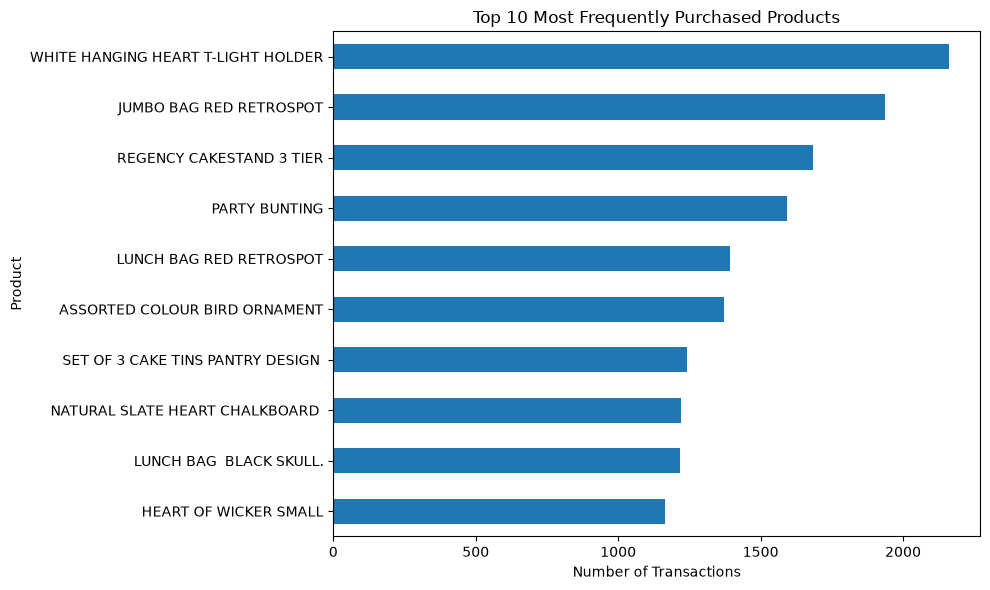

In [52]:
## Visualize the Market Basket Results
#Top 10 most frequently purchased products

top_products = basket.sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Most Frequently Purchased Products")
plt.xlabel("Number of Transactions")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [53]:
# op 10 association rules by Lift

top_rules = rules.sort_values(
    by="lift",
    ascending=False
).head(10).copy()

In [54]:
#Convert the itemsets into readable text:

top_rules["rule"] = (
    top_rules["antecedents"].apply(lambda x: ", ".join(x))
    + " → "
    + top_rules["consequents"].apply(lambda x: ", ".join(x))
)

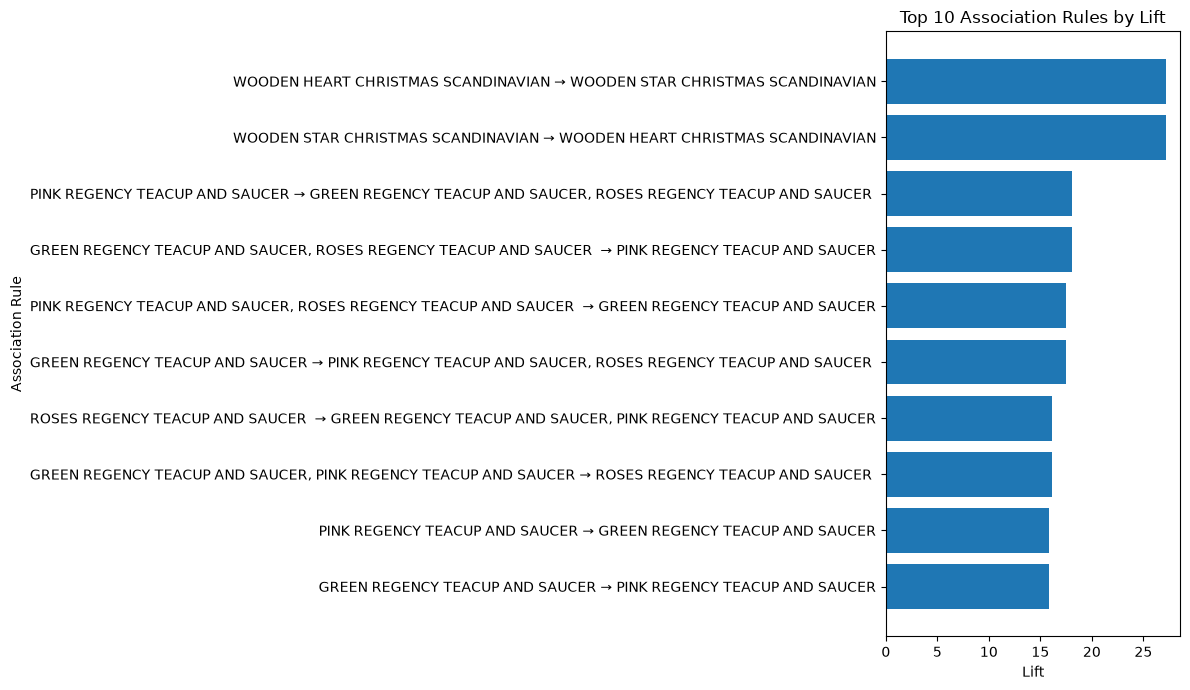

In [55]:
# Then plot:

plt.figure(figsize=(12, 7))

plt.barh(
    top_rules["rule"],
    top_rules["lift"]
)

plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top 10 Association Rules by Lift")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

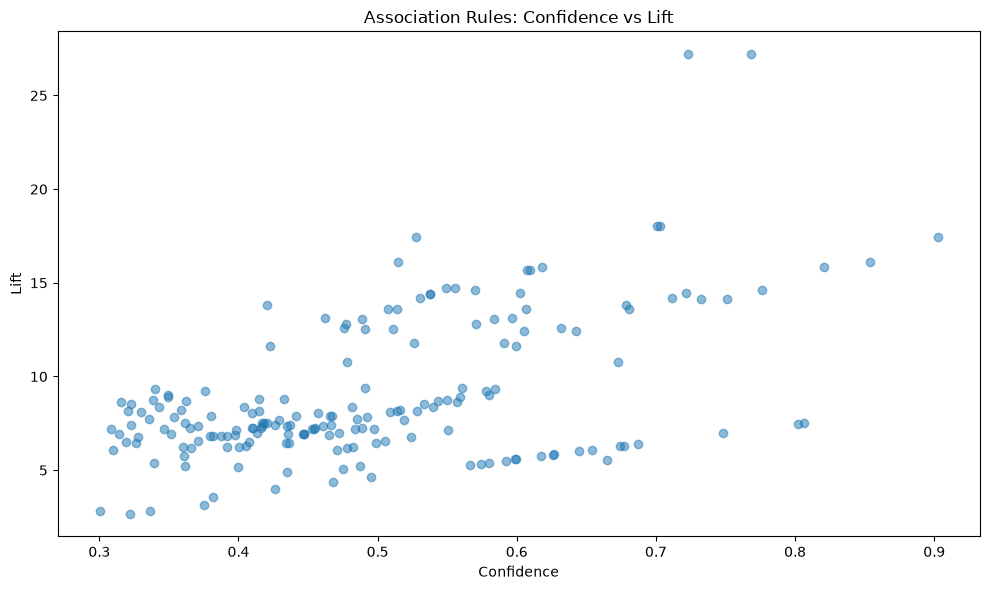

In [56]:
# Confidence vs Lift [This is a useful ML/data-analysis visualization.]

plt.figure(figsize=(10, 6))

plt.scatter(
    rules["confidence"],
    rules["lift"],
    alpha=0.5, 
)

plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Association Rules: Confidence vs Lift")

plt.tight_layout()
plt.show()

In [57]:
## Create a clean recommendation table

recommendations = rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].copy()

In [58]:
# Convert the product sets

recommendations["antecedents"] = recommendations["antecedents"].apply(
    lambda x: ", ".join(x)
)

recommendations["consequents"] = recommendations["consequents"].apply(
    lambda x: ", ".join(x)
)

In [59]:
# Sort by lift:

recommendations = recommendations.sort_values(
    by="lift",
    ascending=False
)

In [60]:
# View:

recommendations.head(20)

,antecedents,consequents,support,confidence,lift
161,WOODEN HEART CHRISTMAS SCANDINAVIAN,WOODEN STAR CHRISTMAS SCANDINAVIAN,0.020423,0.722986,27.197263
162,WOODEN STAR CHRISTMAS SCANDINAVIAN,WOODEN HEART CHRISTMAS SCANDINAVIAN,0.020423,0.768267,27.197263
167,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.027305,0.700855,18.041001
164,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.027305,0.702857,18.041001
165,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.027305,0.902752,17.453534
166,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.027305,0.527897,17.453534
168,ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",0.027305,0.514644,16.099612
163,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.027305,0.854167,16.099612
32,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.031966,0.820513,15.863541
31,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.031966,0.618026,15.863541


In [61]:
# Save the rules [need these later for Streamlit:]

recommendations.to_csv(
    r"C:\Users\Bhumika gs\ML Projects\Market Basket Analysis/data/association_rules.csv",
    index=False
)

In [62]:
basket.to_pickle(
   r"C:\Users\Bhumika gs\ML Projects\Market Basket Analysis/data/basket.pkl"
)

In [63]:
import os

print(os.path.exists(
    r"C:\Users\Bhumika gs\ML Projects\Market Basket Analysis\data\association_rules.csv"
))

True


In [64]:
## Build the Product Recommendation System
# Create the recommendation function

def recommend_products(product, recommendations, top_n=5):
    
    product = product.upper().strip()
    
    matching_rules = recommendations[
        recommendations["antecedents"].str.upper().str.contains(
            product,
            regex=False,
            na=False
        )
    ].copy()
    
    matching_rules = matching_rules.sort_values(
        by=["lift", "confidence"],
        ascending=False
    )
    
    return matching_rules[
        ["antecedents", "consequents", "support", "confidence", "lift"]
    ].head(top_n)

In [65]:
# Test the recommendation system [ Use one of the products from results:]

recommend_products(
    "JUMBO BAG RED RETROSPOT",
    recommendations,
    top_n=5
)

,antecedents,consequents,support,confidence,lift
181,"JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAGE...",JUMBO STORAGE BAG SUKI,0.021311,0.584475,9.320047
176,"JUMBO STORAGE BAG SUKI, JUMBO BAG RED RETROSPOT",JUMBO BAG PINK POLKADOT,0.022476,0.580229,9.020837
179,"JUMBO STORAGE BAG SUKI, JUMBO BAG RED RETROSPOT",JUMBO SHOPPER VINTAGE RED PAISLEY,0.021311,0.550143,8.749366
171,"JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAGE...",JUMBO BAG PINK POLKADOT,0.020312,0.557078,8.660899
175,"JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROSPOT",JUMBO STORAGE BAG SUKI,0.022476,0.515924,8.226926


In [66]:
# Make the output easier to understand

def get_recommendations(product, top_n=5):
    
    result = recommend_products(
        product,
        recommendations,
        top_n
    )
    
    if result.empty:
        print("No recommendations found for this product.")
        return
    
    result = result.copy()
    
    result["confidence"] = (
        result["confidence"] * 100
    ).round(2)
    
    result["support"] = (
        result["support"] * 100
    ).round(2)
    
    result = result.rename(columns={
        "antecedents": "Product Bought",
        "consequents": "Recommended Product",
        "support": "Support (%)",
        "confidence": "Confidence (%)",
        "lift": "Lift"
    })
    
    return result

In [67]:
get_recommendations(
    "JUMBO BAG RED RETROSPOT",
    top_n=5
)

,Product Bought,Recommended Product,Support (%),Confidence (%),Lift
181,"JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAGE...",JUMBO STORAGE BAG SUKI,2.13,58.45,9.320047
176,"JUMBO STORAGE BAG SUKI, JUMBO BAG RED RETROSPOT",JUMBO BAG PINK POLKADOT,2.25,58.02,9.020837
179,"JUMBO STORAGE BAG SUKI, JUMBO BAG RED RETROSPOT",JUMBO SHOPPER VINTAGE RED PAISLEY,2.13,55.01,8.749366
171,"JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAGE...",JUMBO BAG PINK POLKADOT,2.03,55.71,8.660899
175,"JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROSPOT",JUMBO STORAGE BAG SUKI,2.25,51.59,8.226926


In [68]:
# Save the recommendation system

recommendations.to_csv(
    r"C:\Users\Bhumika gs\ML Projects\Market Basket Analysis\data\association_rules.csv",
    index=False
)